In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aiwithcagri/student-performance-for-multi-linear-regression/student_multi.csv


In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv('/kaggle/input/datasets/aiwithcagri/student-performance-for-multi-linear-regression/student_multi.csv')

In [4]:
df.head()

,course_name,class_number,study_hours,last_exam_score,exam_score
0,History,1,4.1,65,61
1,Math,2,9.5,65,95
2,Math,3,7.5,55,90
3,History,1,6.2,72,80
4,Physics,2,2.0,56,45


In [5]:
df.shape

(1615, 5)

In [6]:
df.describe()

,class_number,study_hours,last_exam_score,exam_score
count,1615.000000,1615.000000,1615.000000,1615.000000
mean,2.282972,4.253313,64.780805,59.780805
std,1.195220,2.980575,22.005975,21.461565
min,1.000000,0.500000,30.000000,20.000000
25%,1.000000,1.300000,44.000000,40.000000
50%,2.000000,4.200000,64.000000,59.000000
75%,3.000000,6.800000,86.000000,80.000000
max,4.000000,9.800000,99.000000,100.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615 entries, 0 to 1614
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   course_name      1615 non-null   object 
 1   class_number     1615 non-null   int64  
 2   study_hours      1615 non-null   float64
 3   last_exam_score  1615 non-null   int64  
 4   exam_score       1615 non-null   int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 63.2+ KB


In [8]:
df.isnull().sum()

course_name        0
class_number       0
study_hours        0
last_exam_score    0
exam_score         0
dtype: int64

In [9]:
#there no null values 
#EDA 
df.columns

Index(['course_name', 'class_number', 'study_hours', 'last_exam_score',
       'exam_score'],
      dtype='object')

In [10]:
#categorical data 
df['class_number'].value_counts()

class_number
1    612
4    377
3    315
2    311
Name: count, dtype: int64

In [11]:
#numerical data ->study hours , 'last_exam_score','exam_score'
df['study_hours'].value_counts()

study_hours
0.5    88
0.7    73
2.3    71
5.2    58
1.4    58
       ..
3.9     1
4.0     1
2.5     1
4.5     1
2.9     1
Name: count, Length: 74, dtype: int64

In [12]:
#categorical data 
df['course_name'].value_counts()

course_name
Physics    682
Math       492
History    441
Name: count, dtype: int64

<Axes: xlabel='exam_score', ylabel='Count'>

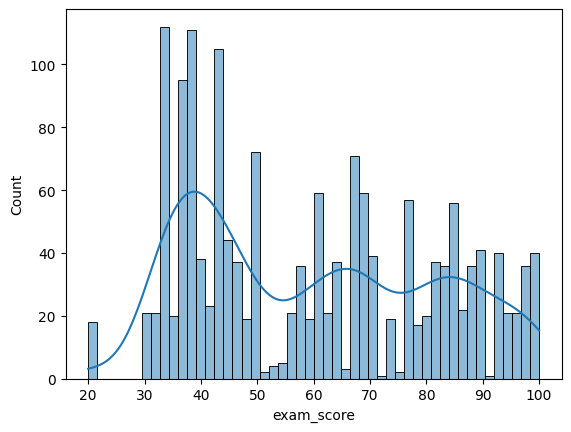

In [13]:
sns.histplot(df['exam_score'], bins = 50 , kde = True)

<Axes: >

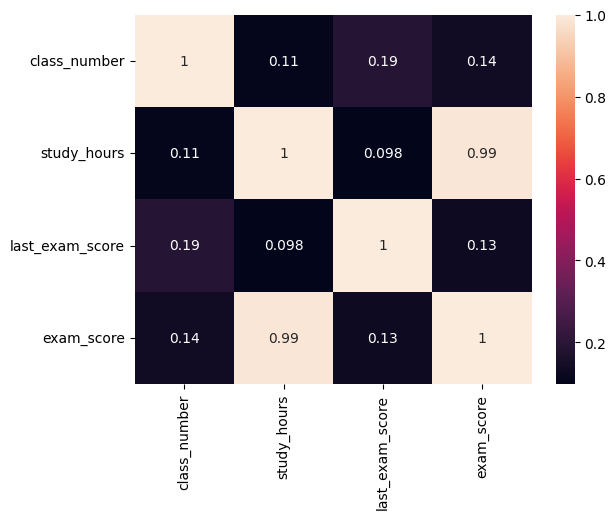

In [14]:
# co relation with numerical data 
df.corr(numeric_only = True)
sns.heatmap(df.corr(numeric_only = True) , annot = True)

([0, 1, 2, 3],
 [Text(0, 0, '1'), Text(1, 0, '2'), Text(2, 0, '3'), Text(3, 0, '4')])

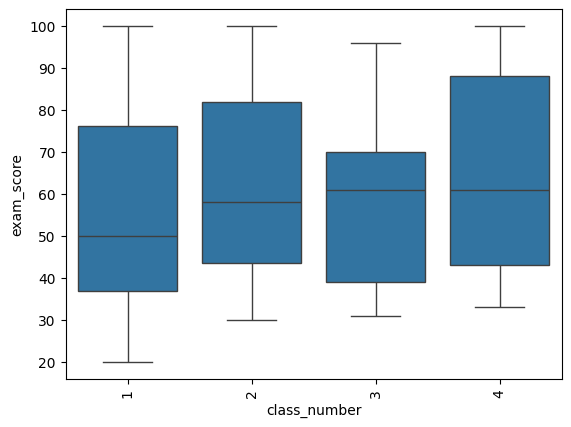

In [15]:
# for the categorical data 
sns.boxplot(data = df , x ='class_number', y = 'exam_score')
plt.xticks(rotation = 90)

([0, 1, 2, 3],
 [Text(0, 0, '1'), Text(1, 0, '2'), Text(2, 0, '3'), Text(3, 0, '4')])

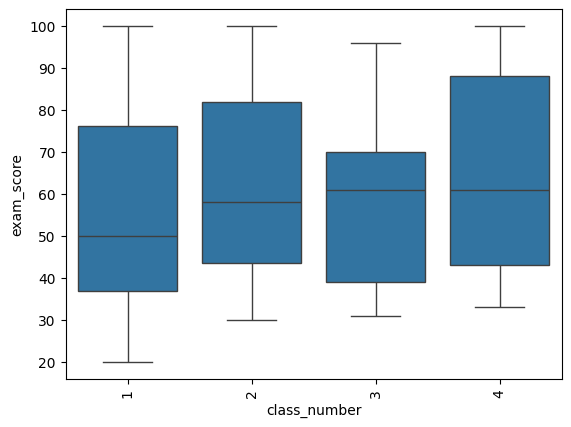

In [16]:
# for the categorical data 
sns.boxplot(data = df , x ='class_number', y = 'exam_score')
plt.xticks(rotation = 90) 

In [17]:
#one hot encoding 
encoded = pd.get_dummies( df,columns =['class_number','course_name'], drop_first = True , dtype = int)
encoded

,study_hours,last_exam_score,exam_score,class_number_2,class_number_3,class_number_4,course_name_Math,course_name_Physics
0,4.1,65,61,0,0,0,0,0
1,9.5,65,95,1,0,0,1,0
2,7.5,55,90,0,1,0,1,0
3,6.2,72,80,0,0,0,0,0
4,2.0,56,45,1,0,0,0,1
...,...,...,...,...,...,...,...,...
1610,5.7,83,67,0,1,0,1,0
1611,2.3,95,49,0,0,1,0,0
1612,0.7,48,32,0,0,0,0,1
1613,7.3,77,82,1,0,0,0,0


In [18]:
#scaling the values 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_col = ['study_hours','last_exam_score','exam_score']
encoded[numeric_col] = scaler.fit_transform(encoded[numeric_col])
encoded


,study_hours,last_exam_score,exam_score,class_number_2,class_number_3,class_number_4,course_name_Math,course_name_Physics
0,-0.051453,0.009964,0.056826,0,0,0,0,0
1,1.760839,0.009964,1.641544,1,0,0,1,0
2,1.089620,-0.444599,1.408497,0,1,0,1,0
3,0.653327,0.328158,0.942404,0,0,0,0,0
4,-0.756233,-0.399143,-0.688924,1,0,0,0,1
...,...,...,...,...,...,...,...,...
1610,0.485522,0.828177,0.336482,0,1,0,1,0
1611,-0.655551,1.373652,-0.502486,0,0,1,0,0
1612,-1.192526,-0.762793,-1.294845,0,0,0,0,1
1613,1.022498,0.555439,1.035622,1,0,0,0,0


In [19]:
# creating 2 model 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
x = encoded.drop('exam_score', axis=1)
y = encoded['exam_score']
x

,study_hours,last_exam_score,class_number_2,class_number_3,class_number_4,course_name_Math,course_name_Physics
0,-0.051453,0.009964,0,0,0,0,0
1,1.760839,0.009964,1,0,0,1,0
2,1.089620,-0.444599,0,1,0,1,0
3,0.653327,0.328158,0,0,0,0,0
4,-0.756233,-0.399143,1,0,0,0,1
...,...,...,...,...,...,...,...
1610,0.485522,0.828177,0,1,0,1,0
1611,-0.655551,1.373652,0,0,1,0,0
1612,-1.192526,-0.762793,0,0,0,0,1
1613,1.022498,0.555439,1,0,0,0,0


In [21]:
X_train, X_test, y_train, y_test = train_test_split( x , y, test_size=0.20, random_state=42)

In [22]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test)
y_pred

array([-0.87851834,  0.78898183,  0.66634289,  0.66634289, -0.56212189,
        0.74590483,  0.06220265,  1.01235757, -0.84734095, -0.13304087,
       -0.9841852 , -0.56212189,  1.79147442, -1.0572152 , -0.23552268,
       -1.30363384, -0.84734095, -1.05617183,  1.79147442, -1.09817229,
       -1.21572442,  1.79085942,  0.06220265, -0.56212189,  1.26376447,
        0.70588315,  0.34286962, -1.04593185,  1.54378729,  1.27794496,
       -0.95683708, -1.03943846,  0.85343185, -0.87635366,  0.71251063,
       -1.14334225,  0.92773182, -0.81621341, -1.04593185, -0.72748588,
       -0.72748588,  1.79147442,  0.25779947, -0.28441443,  1.20683881,
        1.46021425,  0.48858011,  1.79147442,  0.00251411, -0.3578728 ,
       -0.98291523,  1.43938252, -0.84562765, -1.06165418,  1.53276188,
        1.7345816 ,  1.48835672, -0.23552268, -1.06888609, -1.16461837,
        0.70929806,  1.21237985, -0.3578728 ,  1.7345816 , -1.04593185,
       -1.2665261 , -1.02183115,  1.27794496,  0.73217348, -0.56

In [24]:
y_test

135    -0.968580
1281    0.849185
1117    0.476310
998     0.476310
808    -0.455877
          ...   
548    -1.015189
286     1.128841
506    -0.968580
1298    0.429701
514     0.010217
Name: exam_score, Length: 323, dtype: float64

In [25]:
r2 = r2_score(y_test, y_pred)
r2

0.983370145278391

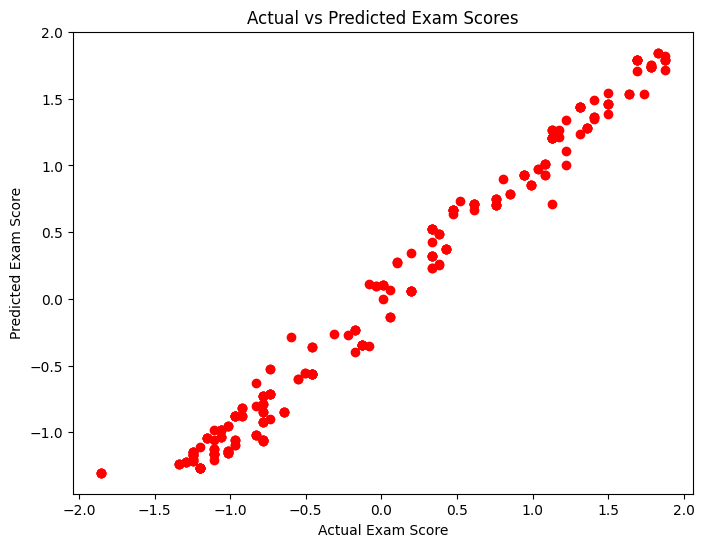

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color = 'red')
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")
plt.show()

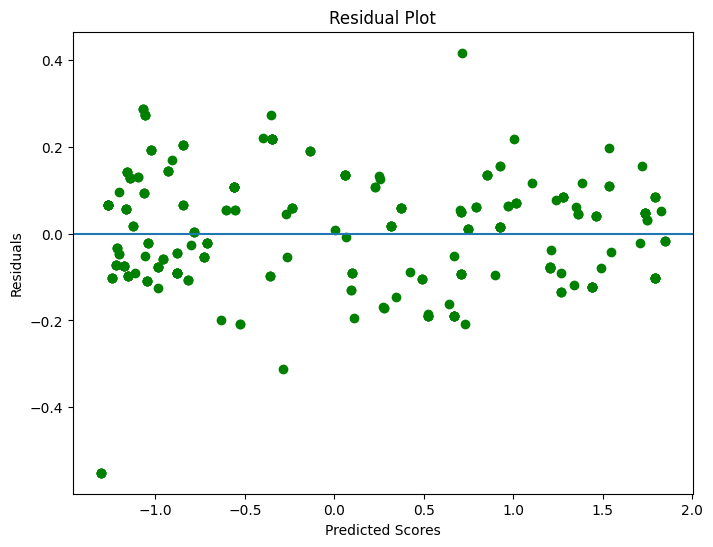

In [27]:
#Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, color = 'green')
plt.axhline(y=0)
plt.xlabel("Predicted Scores")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

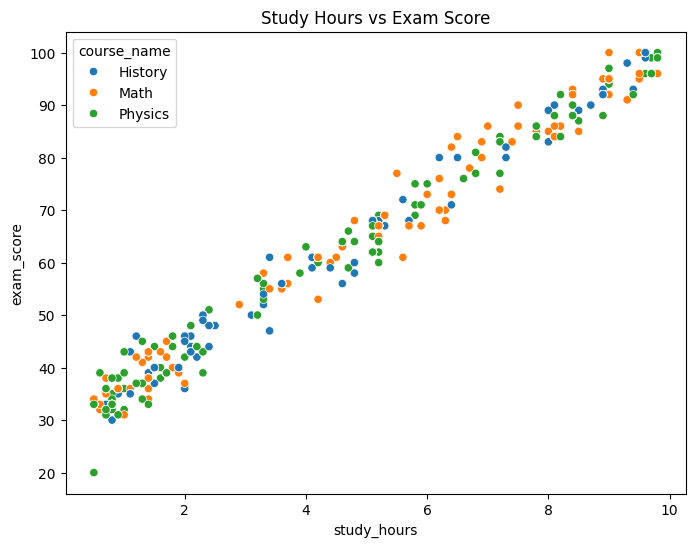

In [28]:
#Study Hours vs Exam Score
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='study_hours',
    y='exam_score',
    hue='course_name'
)

plt.title('Study Hours vs Exam Score')
plt.show()

In [29]:
#multiple regression
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.983370145278391
MAE: 0.10553547637558802
RMSE: 0.13321840469622925


In [31]:
coefficients = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
})

print(coefficients)

               Feature  Coefficient
0          study_hours     0.983843
1      last_exam_score     0.022953
2       class_number_2    -0.032796
3       class_number_3     0.026804
4       class_number_4     0.070891
5     course_name_Math     0.015080
6  course_name_Physics    -0.017855


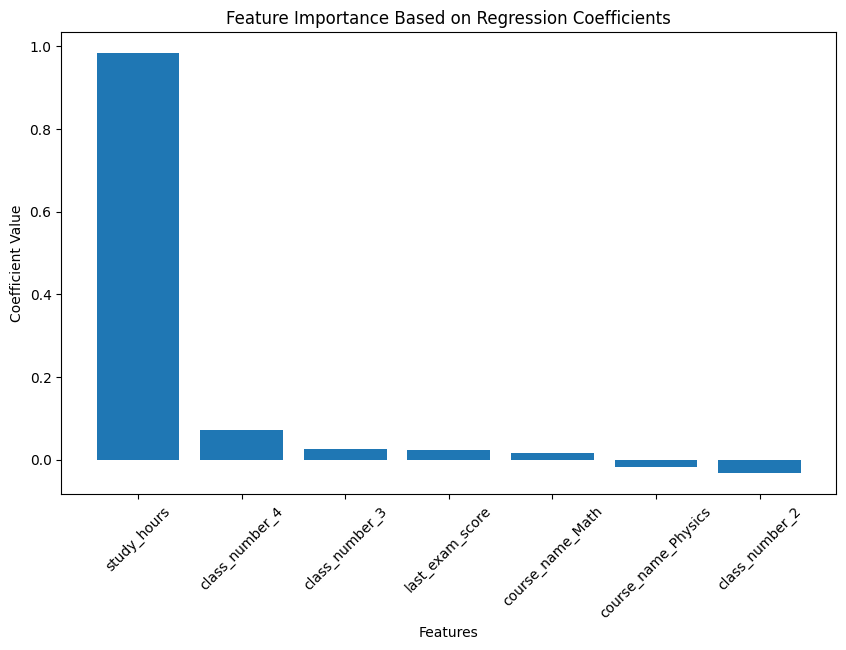

In [32]:
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(coefficients['Feature'], coefficients['Coefficient'])
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('Feature Importance Based on Regression Coefficients')
plt.xticks(rotation=45)
plt.show()